In [8]:
from google.colab import files
uploaded=files.upload()

Saving spam[1].csv to spam[1].csv


In [60]:
import pandas as pd

spam_data = pd.read_csv("spam[1].csv",encoding='latin1')

spam_data.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [61]:
spam_data=spam_data[['v1','v2']]

In [62]:
spam_data.columns=['label','message']

In [63]:
spam_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [64]:
# displaying dataset information
spam_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


In [65]:
# checking for missing values
spam_data.isnull().sum()

,0
label,0
message,0


In [21]:
# coverting text lables to the numerical values
spam_data['label']=spam_data['label'].map({'ham':0,'spam':1})


In [69]:
# displaying the updated dataset
spam_data.head()

,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [23]:
import matplotlib.pyplot as plt

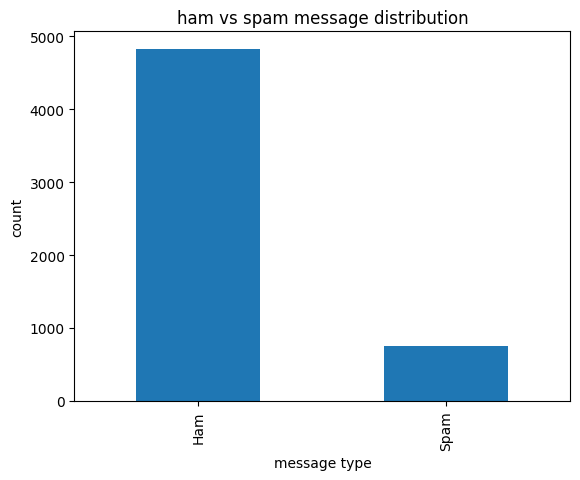

In [24]:
spam_data['label'].value_counts().plot(kind='bar')
plt.xticks([0,1],['Ham','Spam'])
plt.xlabel("message type")
plt.ylabel("count")
plt.title("ham vs spam message distribution")
plt.show()

In [25]:
x=spam_data['message']
y=spam_data['label']

In [42]:
from sklearn.model_selection import train_test_split

# Splitting data

x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [29]:
tfidf_vectorizer = TfidfVectorizer()

In [43]:

x_train = tfidf_vectorizer.fit_transform(x_train)
x_test = tfidf_vectorizer.transform(x_test)

In [44]:
from sklearn.linear_model import LogisticRegression

In [45]:
spam_classifier = LogisticRegression()

In [47]:
spam_classifier.fit(x_train, y_train)

LogisticRegression()

In [67]:
# Predicting the test data

prediction = spam_classifier.predict(x_test)

In [68]:
from sklearn.metrics import accuracy_score

# accuracy calculation

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.967713004484305


In [66]:
# Testing custom message

custom_message = ["come home by 10"]

# Converting message

message_vector = tfidf_vectorizer.transform(custom_message)

# Predicting message

result = spam_classifier.predict(message_vector)

# Displaying result

if result[0] == 1:
    print("This message is SPAM")
else:
    print("This message is HAM")

This message is HAM
